# AP 155 Lab Exercise
---
## Exercise 2: Numbers, Subtractive Cancellation

_Instructions_: 
- **Report figure:** Two Figures (see *Problem 2: Rewriting functions...*) - Plot f(x) vs. x using the manual evaluation (the one with catastrophic cancellation) vs. the "better function". In each figure, show the area where the catastrophic cancellation occurs. There are two functions discussed in the exercise, hence two figures (Bonus: also compare with different hardware floating-point precisions: 16/32/64/128-bit)
- **Report discussion:** Two Questions: 
    - (See Problem 1) Why do the "bad" and "good" formulas of the roots give out the values they do (what makes "good" good)? What led to the difference between the obtained values?
    - (See Problem 2) In each of the two functions discussed, for which values of x does the catastrophic cancellation occur (include here what the expected values were)? How were the catastrophic cancellations remedied? 
- **Code**: Complete the codes and ensure they are functional, error-free, readable, and efficient (where needed). Include a concise markdown documentation highlighting the critical steps of your algorithm for each problem.

### Student Information
- _Full Name (Last Name, First Name)_: De Casa, Samantha Claire
- _Student No._: 2023-15141
- _Section_: THU-TX-1

### Grading Information (c/o Lab Instructor)
- [Rubrics description link](https://drive.google.com/file/d/1G9tPPcyMUag91g_R02O0wsGYPiZWy5Nn/view?usp=drive_link) (Note: percentages may still be tweaked)

| Criteria | Score | Subtotal |
| --- | --- | --- |
| Report figure | XX | 20 |
| Report discussion | XX | 20|
| Code readability | XX | 20 |
| Code efficiency | XX | 20 | 
| Code appropriateness  | XX | 20 | 
| **TOTAL** | XXX | 100 |

_Date and Time Scored (MM/DD/YYYY HH:MM AM/PM):_:_

---
## Section 1: Report

### Report discussion

PROBLEM 1:

Subtractive/catastrophic cancellation is essentially the loss of precision when subtracting nearly equal numbers that are subject to small rounding errors. Equation 2.93, specifically $x_+$ or the `xbad_plus()`function, is "flawed" because the numerator suffers from subtractive cancellation. This happens because $-b$ and $+\sqrt{b^2 - 4ac}$ are nearly the same magnitude but they differ in sign. What makes the `xgood_plus()` function better is that it avoids this problem by utilizing the `x_minus()` function. Here,  subtractive cancellation is avoided because $-b$ and $-\sqrt{b^2 - 4ac}$ have the same sign so they add up instead of canceling each other out. In the first place, the reason why catastrophic cancellation happens is because of limited computer precision.

PROBLEM 2:

For this function: $f(x) = \sqrt{x^2 + x} - x$, catastrophic cancellation occurs at larger values of $x$. As can be seen from figure 1.2, catastrophic cancellation starts somewhere between $x = 4 \times 10^{15}$ and $x = 6 \times 10^{15}$ but it becomes increasingly problematic near $x = 10 \times 10^{15}$. This problem can be remedied by multiplying the function to its conjugate to modify the term which causes the subtractive cancellation. The expected value of the modified function is $0.5$ as seen in figure 1.2.

For this function: $f(x) = \frac{e^x-1}{x}$, catastrophic cancellation at very small values of $x$. Based on figure 2.1, it is evident that catastrophic cancellation is more prominent near $x = 0$. This problem can be remedied by replacing the denominator of the function with $\log(e^x)$. The expected value of the modified function is $1$ as seen Figure 2.2.


## Section 2 (Problems and Code)

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import math

### Problem 1: Quadratic Equation (Gezerlis Problem 2.6)
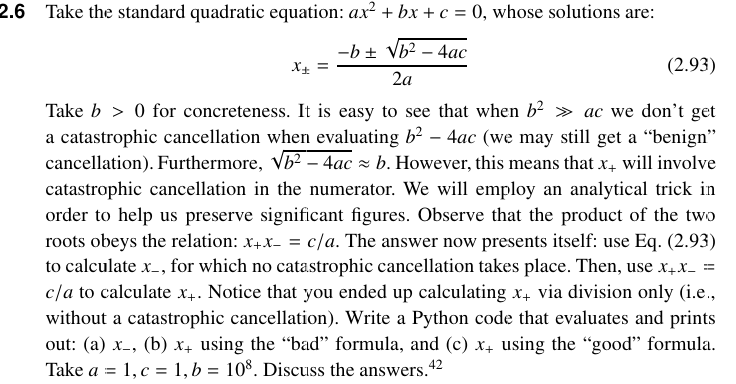

In [26]:
def x_minus(a = 1, b = 10**8, c = 1): #here's the formula for solving the root x-
    return (-b - np.sqrt(b**2 - 4*a*c))/2*a
    
print(x_minus())

-100000000.0


In [28]:
'''this shows how rounding takes place in x_minus()'''
print(b**2 - 4*a*c)
print(np.sqrt(b**2 - 4*a*c))
print(-b - np.sqrt(b**2 - 4*a*c))
print((-b - np.sqrt(b**2 - 4*a*c))/2*a)

9999999999999996
99999999.99999999
-200000000.0
-100000000.0


In [32]:
def xbad_plus(a = 1, b = 10**8, c = 1): #here's the "bad" formula for solving the root x+
    return (-b + np.sqrt(b**2 - 4*a*c))/2*a

print(xbad_plus())

-7.450580596923828e-09


In [31]:
'''this shows how rounding takes place in xbad_plus()'''
a = 1
b = 10**8
c = 1

print(b**2 - 4*a*c)
print(np.sqrt(b**2 - 4*a*c))
print(-b + np.sqrt(b**2 - 4*a*c))
print((-b + np.sqrt(b**2 - 4*a*c))/2*a)

9999999999999996
99999999.99999999
-1.4901161193847656e-08
-7.450580596923828e-09


In [33]:
def xgood_plus(a = 1, b = 10**8, c = 1): #here's the "good" formula for solving the root x+
    return c/(a*x_minus())

print(xg_plus())

-1e-08


#### Problem 1 code summary
The functions defined above are essentially the different formulas for solving the roots of a quadratic equation. The `xbad_plus()` and `x_minus()` functions are simply the quadratic formulas (Equation 2.93) so the code is pretty straightforward. The `xgood_plus()` function has a different approach for solving $x_+$---it obeys the relation $x_+x_- = \frac{c}{a}$ so I made sure to utilize the `x_minus()` function in its code for efficiency.

---


### Problem 2: Rewriting Functions to avoid subtractive cancellation

### Part 1: $ f(x) = \sqrt{x^2 + x} - x $

Consider the function 
$$ f(x) = \sqrt{x^2 + x} - x $$

- For which values of x does the catastrophic cancellation occur? 
- How can we rewrite the function to avoid catastrophic cancellation? 
- [FIGURE] Plot f(x) vs. x using the manual evaluation vs. the rewritten function. In the figure, show the area where the catastrophic cancellation occurs. (Bonus: also compare with different hardware floating-point precisions: 16/32/64/128-bit)

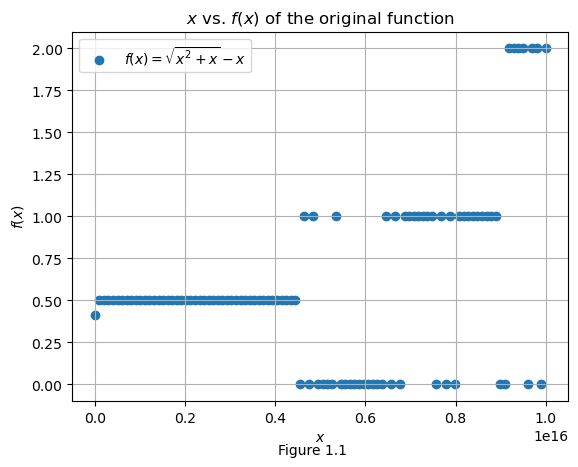

In [127]:
def func1_original(x): #here's the original function
    return np.sqrt(x**2 + x) - x

def func1_modified(x): #here's how I rewrote the function
    return x/(np.sqrt(x**2 + x) + x)

xs = np.linspace(1, 10e15, 100) #this line creates evenly spaced x-values 
ys_original = np.array([func1_original(xs)]) 
ys_modified = np.array([func1_modified(xs)])

caption = "Figure 1.1"

plt.scatter(xs, ys_original, label=r'$f(x) = \sqrt{x^2 + x} - x$')
plt.title(r'$x$ vs. $f(x)$ of the original function')
plt.xlabel("$x$")
plt.ylabel("$f(x)$")
plt.legend()
plt.grid(True)
plt.figtext(0.5, 0, caption, wrap=True, ha='center')

plt.show()

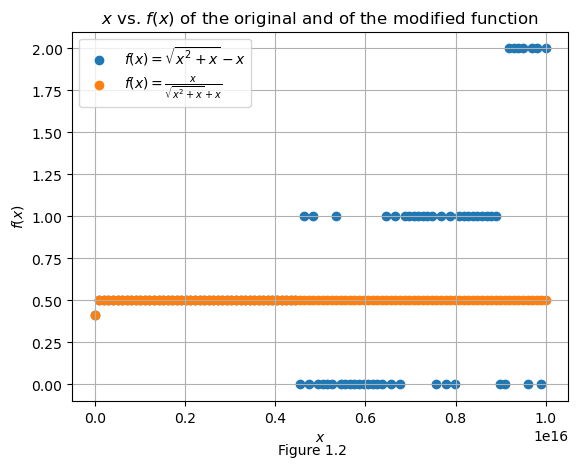

In [128]:
caption = "Figure 1.2"

plt.scatter(xs, ys_original, label=r'$f(x) = \sqrt{x^2 + x} - x$')
plt.scatter(xs, ys_modified, label=r'$f(x) = \frac{x}{\sqrt{x^2 + x} + x}$')
plt.title(r'$x$ vs. $f(x)$ of the original and of the modified function')
plt.xlabel("$x$")
plt.ylabel("$f(x)$")
plt.legend()
plt.grid(True)
plt.figtext(0.5, 0, caption, wrap=True, ha='center')

plt.show()

In [129]:
#this is to check for x values in which catastrophic cancellation occur
sample1 = np.array([1, 10, 10**3, 10**7, 10**9, 10**12, 10**14, 10**15])

for x in sample1:
    print(x, func1_original(x))

1 0.41421356237309515
10 0.4880884817015154
1000 0.4998750624610011
10000000 0.49999998696148396
1000000000 0.5
1000000000000 -998584455862.5013
100000000000000 -99997883850662.08
1000000000000000 -999997746570553.5


#### Part 2: $ f(x) = \frac{e^x - 1}{x}$

Consider the function 
$$ f(x) = \frac{e^x - 1}{x}$$

- For which values of x does the catastrophic cancellation occur? 
- How can we resolve the catastrophic cancellation? 
- [FIGURE] Plot the f(x) vs. x using the manual evaluation vs. the numpy special function. In the figure, show the area where the catastrophic cancellation occurs. (Bonus: also compare with different hardware floating-point precisions: 16/32/64/128-bit)



/tmp/ipykernel_2292215/2107481376.py:5: RuntimeWarning: invalid value encountered in divide
  return (np.exp(x) - 1)/(np.log(np.exp(x)))


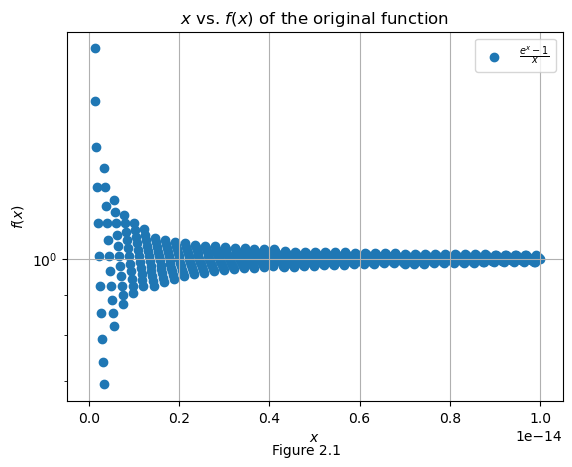

In [131]:
def func2_original(x): #here's the original function
    return (np.exp(x) - 1)/x

def func2_modified(x): #here's how I rewrote the function
    return (np.exp(x) - 1)/(np.log(np.exp(x)))

xs = np.linspace(10e-25, 10e-15, 500) #this line creates evenly spaced x-values 
ys_original = np.array([func2_orig(xs)])
ys_modified = np.array([func2_modified(xs)])

caption = "Figure 2.1"

plt.scatter(xs, ys_original, label=r'$\frac{e^x-1}{x}$')
plt.title(r'$x$ vs. $f(x)$ of the original function')
plt.xlabel("$x$")
plt.ylabel("$f(x)$")
plt.yscale("log")
plt.legend()
plt.grid(True)
plt.figtext(0.5, 0, caption, wrap=True, ha='center')

plt.show()

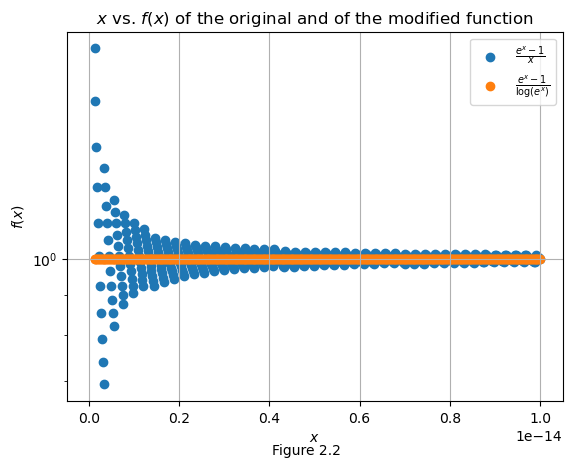

In [132]:
caption = "Figure 2.2"

plt.scatter(xs, ys_original, label=r'$\frac{e^x-1}{x}$')
plt.scatter(xs, ys_modified, label=r'$\frac{e^x-1}{\log(e^x)}$')
plt.title(r'$x$ vs. $f(x)$ of the original and of the modified function')
plt.xlabel("$x$")
plt.ylabel("$f(x)$")
plt.yscale("log")
plt.legend()
plt.grid(True)
plt.figtext(0.5, 0, caption, wrap=True, ha='center')

plt.show()

In [133]:
#this is to check for x values in which catastrophic cancellation occur
sample2 = np.array([10e-24, 10e-22, 10e-20, 10e-17, 10e-15])

for x in sample2:
    print(x, func1_original(x))

1e-23 3.1622776601583793e-12
1e-21 3.162277660068379e-11
1e-19 3.1622776591683797e-10
1e-16 9.9999999e-09
1e-14 9.99999900000005e-08


#### Problem 2 code summary
In this problem, I attempted to rewrite $f(x) = \sqrt{x^2 + x} - x$ and $f(x) = \frac{e^x-1}{x}$ as `func1_modified(x)`and `func2_modified(x)` respectively, to avoid subtractive cancellation. I used a scatterplot because it makes it easier to spot outliers in the dataset; and this is particularly useful since we're trying to figure out at which values of $x$ does the catastrophic cancellation occur. 

---

## Section 3 (Notes)

### Floating-point representation
Python uses 64-bit float by default for any number you type in with a decimal point. Different floating point precision can be used at a lower level, which we can go around by using [Numpy dtypes](https://numpy.org/doc/stable/reference/arrays.dtypes.html). 

Useful links:
* [(Goldberg, 1991) *What every computer scientist should know about floating-point arithmetic*](https://dl.acm.org/doi/10.1145/103162.103163)
* [Wikipedia - Floating-point arithmetic](https://en.wikipedia.org/wiki/Floating-point_arithmetic)
* [Data types - NumPy](https://numpy.org/doc/stable/user/basics.types.html)
* [decimal — Decimal fixed-point and floating-point arithmetic](https://docs.python.org/3/library/decimal.html)
* [fractions — Rational numbers](https://docs.python.org/3/library/fractions.html)

In [2]:
import matplotlib.pyplot as plt
import numpy as np

from decimal import Decimal
from fractions import Fraction

# Classic floating point quirks example
print(0.1 + 0.2)

# How about increasing precision?
print(np.float128(0.1) + np.float128(0.2))

# How bad is decreasing precision?
print(np.float16(0.1) + np.float16(0.2))

# Closest we could get to fixed-point arithmetic: decimal
print(Decimal(0.1) + Decimal(0.2))

# How about using an explicit Fraction object type?
print(float(Fraction(1, 10) + Fraction(1, 5)))

0.30000000000000004
0.30000000000000001665
0.2998
0.3000000000000000166533453694
0.3
